# GC Example 05: Orbital Properties — Pericenter vs Apocenter

**EPS Research — Milky Way Globular Cluster Corpus v1.3.1**

Baumgardt (2023) provides orbital pericenter and apocenter
computed in the Irrgang et al. (2013) Milky Way potential.
Orbital eccentricity e = (r_apo - r_peri)/(r_apo + r_peri).

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907765  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.1.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


In [2]:
orbits = []
for c in clusters:
    b = c.get('baumgardt2023', {})
    if b and b.get('r_peri_kpc') is not None and b.get('r_apo_kpc') is not None:
        r_peri = b['r_peri_kpc']
        r_apo  = b['r_apo_kpc']
        ecc    = (r_apo - r_peri) / (r_apo + r_peri) if (r_apo + r_peri) > 0 else 0
        orbits.append({'cluster': c['cluster_id'], 'r_peri': r_peri,
                       'r_apo': r_apo, 'ecc': ecc,
                       'mass': b.get('mass_msun', 0)})

eccs = [o['ecc'] for o in orbits]
print(f"Clusters with orbital data: {len(orbits)}")
print(f"Eccentricity range: {min(eccs):.3f} -- {max(eccs):.3f}")
print(f"Median eccentricity: {np.median(eccs):.3f}")
print(f"Highly eccentric (e>0.8): {sum(1 for e in eccs if e>0.8)}")

# Most extreme orbits
print("\nMost eccentric orbits:")
for o in sorted(orbits, key=lambda x: -x['ecc'])[:5]:
    print(f"  {o['cluster']:<12} e={o['ecc']:.3f}  r_peri={o['r_peri']:.1f}  r_apo={o['r_apo']:.1f} kpc")


Clusters with orbital data: 154
Eccentricity range: 0.091 -- 0.985
Median eccentricity: 0.638
Highly eccentric (e>0.8): 28

Most eccentric orbits:
  Pal 14       e=0.985  r_peri=3.8  r_apo=500.0 kpc
  NGC 1904     e=0.970  r_peri=0.3  r_apo=19.6 kpc
  Pal 2        e=0.965  r_peri=0.7  r_apo=38.8 kpc
  Pal 15       e=0.941  r_peri=1.5  r_apo=49.7 kpc
  NGC 6934     e=0.918  r_peri=0.7  r_apo=16.0 kpc


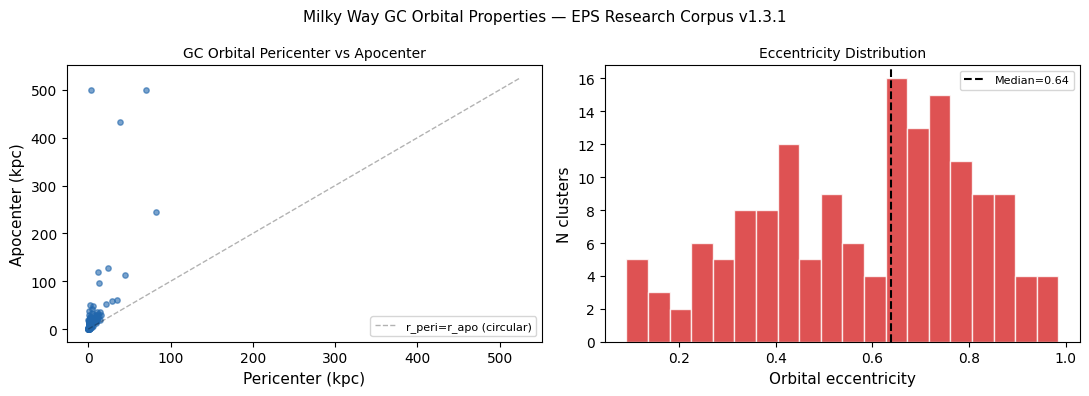

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

r_peri = [o['r_peri'] for o in orbits]
r_apo  = [o['r_apo']  for o in orbits]

axes[0].scatter(r_peri, r_apo, s=15, alpha=0.6, color='#2166ac')
lim = [0, max(r_apo) * 1.05]
axes[0].plot(lim, lim, 'k--', lw=1, alpha=0.3, label='r_peri=r_apo (circular)')
axes[0].set_xlabel('Pericenter (kpc)', fontsize=11)
axes[0].set_ylabel('Apocenter (kpc)', fontsize=11)
axes[0].set_title('GC Orbital Pericenter vs Apocenter', fontsize=10)
axes[0].legend(fontsize=8)

axes[1].hist(eccs, bins=20, color='#d62728', alpha=0.8, edgecolor='white')
axes[1].axvline(np.median(eccs), color='black', ls='--', lw=1.5,
                label=f'Median={np.median(eccs):.2f}')
axes[1].set_xlabel('Orbital eccentricity', fontsize=11)
axes[1].set_ylabel('N clusters', fontsize=11)
axes[1].set_title('Eccentricity Distribution', fontsize=10)
axes[1].legend(fontsize=8)

plt.suptitle('Milky Way GC Orbital Properties — EPS Research Corpus v1.3.1', fontsize=11)
plt.tight_layout()
plt.savefig('gc05_orbital_properties.png', dpi=150, bbox_inches='tight')
plt.show()